# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `species` using the other variables in the dataset.

**Dummify** all variables that require this.

In [1]:
import pandas as pd

penguins = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
penguins = penguins.dropna()

penguins.head()

penguins_dum = pd.get_dummies(penguins, columns=["island", "sex"], drop_first=True)

penguins_dum.head()


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,Adelie,39.1,18.7,181.0,3750.0,False,True,True
1,Adelie,39.5,17.4,186.0,3800.0,False,True,False
2,Adelie,40.3,18.0,195.0,3250.0,False,True,False
4,Adelie,36.7,19.3,193.0,3450.0,False,True,False
5,Adelie,39.3,20.6,190.0,3650.0,False,True,True


Let's use the other variables to predict `species`. Prepare your data and fit the following models on the entire dataset:

* Two kNN models (for different values of K)
* Two decision tree models (for different complexities of trees)

Compute the following, for each of your models, on test data. Keep in mind that you may need to stratify your creation of the training and test data.

* Confusion matrix
* Overall Accuracy
* Precision, Recall, AUC, and F1-score for each species

Create one ROC plot for the species of your choice.

kNN3
Confusion matrix:
 [[37  4  3]
 [ 9 10  1]
 [ 4  0 32]]
Accuracy: 0.79
Precision: [0.74       0.71428571 0.88888889]
Recall: [0.84090909 0.5        0.88888889]
F1: [0.78723404 0.58823529 0.88888889]

kNN10
Confusion matrix:
 [[41  1  2]
 [17  2  1]
 [ 1  1 34]]
Accuracy: 0.77
Precision: [0.69491525 0.5        0.91891892]
Recall: [0.93181818 0.1        0.94444444]
F1: [0.7961165  0.16666667 0.93150685]

Tree3
Confusion matrix:
 [[44  0  0]
 [ 0 20  0]
 [ 2  0 34]]
Accuracy: 0.98
Precision: [0.95652174 1.         1.        ]
Recall: [1.         1.         0.94444444]
F1: [0.97777778 1.         0.97142857]

TreeFull
Confusion matrix:
 [[44  0  0]
 [ 0 20  0]
 [ 2  0 34]]
Accuracy: 0.98
Precision: [0.95652174 1.         1.        ]
Recall: [1.         1.         0.94444444]
F1: [0.97777778 1.         0.97142857]



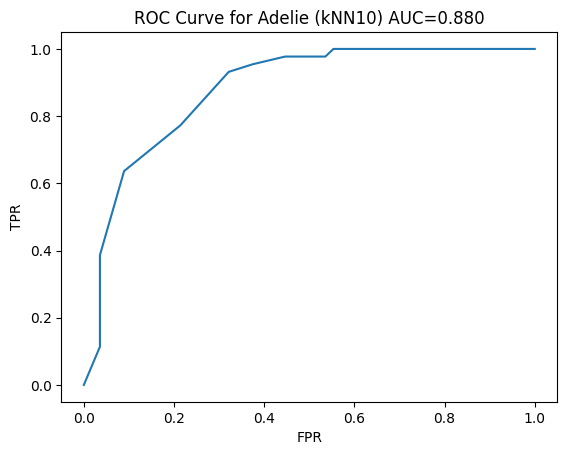

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

X = penguins_dum.drop(columns=["species"]).values
y = penguins_dum["species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

knn3 = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
knn10 = KNeighborsClassifier(n_neighbors=10).fit(X_train, y_train)
tree3 = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)
tree_full = DecisionTreeClassifier().fit(X_train, y_train)

models = {"kNN3": knn3, "kNN10": knn10, "Tree3": tree3, "TreeFull": tree_full}
labels = np.unique(y)

for name, m in models.items():
    pred = m.predict(X_test)
    cm = confusion_matrix(y_test, pred, labels=labels)
    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, labels=labels, average=None)

    print(name)
    print("Confusion matrix:\n", cm)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print()

target = "Adelie"
idx = list(labels).index(target)
y_bin = (y_test == target).astype(int)
y_score = knn10.predict_proba(X_test)[:, idx]

fpr, tpr, _ = roc_curve(y_bin, y_score)
auc = roc_auc_score(y_bin, y_score)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"ROC Curve for {target} (kNN10) AUC={auc:.3f}")
plt.show()
